# K-Nearest Neighbors

## Import Packages

In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, fbeta_score, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier

## Read-In Data

In [2]:
X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')
y_train = np.array(pd.read_csv('train_labels.csv')).reshape(-1,)
y_test = np.array(pd.read_csv('test_labels.csv')).reshape(-1,)

## Run KNN

In [3]:
def score(y_true, y_pred):
    return np.array(fbeta_score(y_true, y_pred, average=None, beta=2)).min()

scorer = make_scorer(score)

### No Imbalance Fix

#### Find Optimal K and Distance Metric

In [4]:
k_vals = range(1, 10, 2)
metrics = ['l1', 'l2', 'cosine']
param_grid = dict(knn__n_neighbors=k_vals, knn__metric=metrics)
pipe = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(weights='distance'))
])

knn = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
knn = knn.fit(X_train, y_train)

The best K value and metric combination is k=1 and the cosine metric with a f_2 score of 0.4873


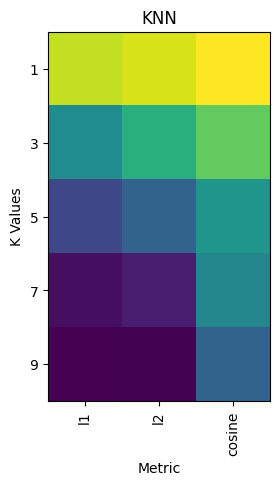

In [5]:
print(f'The best K value and metric combination is k={knn.best_params_["knn__n_neighbors"]} and the {knn.best_params_["knn__metric"]} metric with a f_2 score of {knn.best_score_:.4f}')

plt.imshow(knn.cv_results_['mean_test_score'].reshape(len(metrics), len(k_vals)).transpose())
plt.yticks(np.arange(len(k_vals)), k_vals)
plt.ylabel('K Values')
plt.xticks(np.arange(len(metrics)), metrics, rotation=90)
plt.xlabel('Metric')
plt.title('KNN')
plt.show()

#### Use Optimal K and Distance Metric

In [6]:
print(classification_report(y_test, knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1679
           1       0.67      0.54      0.60       119
           2       0.66      0.69      0.68        36

    accuracy                           0.94      1834
   macro avg       0.76      0.74      0.75      1834
weighted avg       0.94      0.94      0.94      1834



### Use SMOTE

#### Find Optimal K and Distance Metric

In [7]:
k_vals = range(1, 50, 2)
metrics = ['l1', 'l2', 'cosine']
param_grid = dict(knn__n_neighbors=k_vals, knn__metric=metrics)
pipe = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('knn', KNeighborsClassifier(weights='distance'))
])

knn_smote = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
knn_smote = knn_smote.fit(X_train, y_train)

The best K value and metric combination is k=23 and the l1 metric with a f_2 score of 0.6245


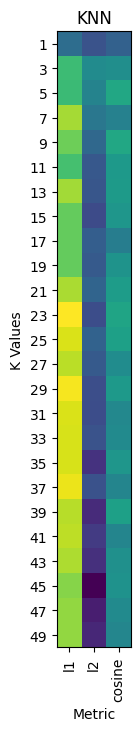

In [8]:
print(f'The best K value and metric combination is k={knn_smote.best_params_["knn__n_neighbors"]} and the {knn_smote.best_params_["knn__metric"]} metric with a f_2 score of {knn_smote.best_score_:.4f}')

plt.figure(figsize=(12, 8))
plt.imshow(knn_smote.cv_results_['mean_test_score'].reshape(len(metrics), len(k_vals)).transpose())
plt.yticks(np.arange(len(k_vals)), k_vals)
plt.ylabel('K Values')
plt.xticks(np.arange(len(metrics)), metrics, rotation=90)
plt.xlabel('Metric')
plt.title('KNN')
plt.show()

#### Use Optimal K and Distance Metric

In [9]:
print(classification_report(y_test, knn_smote.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1679
           1       0.31      0.76      0.44       119
           2       0.35      0.89      0.50        36

    accuracy                           0.84      1834
   macro avg       0.55      0.83      0.62      1834
weighted avg       0.92      0.84      0.87      1834



### Use SMOTEENN

#### Find Optimal K and Distance Metric

In [10]:
k_vals = range(1, 50, 2)
metrics = ['l1', 'l2', 'cosine']
param_grid = dict(knn__n_neighbors=k_vals, knn__metric=metrics)
pipe = Pipeline(steps=[
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('smoteenn', SMOTEENN()),
    ('knn', KNeighborsClassifier(weights='distance'))
])

knn_smoteenn = GridSearchCV(pipe, param_grid, cv=5, scoring=scorer)
knn_smoteenn = knn_smoteenn.fit(X_train, y_train)

The best K value and metric combination is k=29 and the l1 metric with a f_2 score of 0.5829


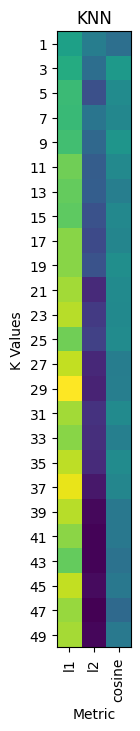

In [11]:
print(f'The best K value and metric combination is k={knn_smoteenn.best_params_["knn__n_neighbors"]} and the {knn_smoteenn.best_params_["knn__metric"]} metric with a f_2 score of {knn_smoteenn.best_score_:.4f}')

plt.figure(figsize=(12, 8))
plt.imshow(knn_smoteenn.cv_results_['mean_test_score'].reshape(len(metrics), len(k_vals)).transpose())
plt.yticks(np.arange(len(k_vals)), k_vals)
plt.ylabel('K Values')
plt.xticks(np.arange(len(metrics)), metrics, rotation=90)
plt.xlabel('Metric')
plt.title('KNN')
plt.show()

#### Use Optimal K and Distance Metric

In [12]:
print(classification_report(y_test, knn_smote.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1679
           1       0.31      0.76      0.44       119
           2       0.35      0.89      0.50        36

    accuracy                           0.84      1834
   macro avg       0.55      0.83      0.62      1834
weighted avg       0.92      0.84      0.87      1834

